# Dynamic mode checkpointing

This notebook demonstrates how to save and restore the state of a DALI *dynamic mode* data loading loop. In dynamic mode, the stateful objects are individual readers and random number generators - they expose `get_state` / `set_state` methods, and the [`Checkpoint`](checkpointing.rst) helper aggregates the state of a registered set of them into a single serialized blob.

The example reads JPEG images from `DALI_EXTRA_PATH/db/single/mixed` with `ndd.readers.File`, decodes them, and applies a rotation by a random angle in the range `(-30, 30)` degrees. We will run the loop for a couple of warmup iterations, save a checkpoint, and then build a fresh reader + RNG pair that resumes from exactly the captured point.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import nvidia.dali.experimental.dynamic as ndd

IMAGE_DIR = os.path.join(os.environ["DALI_EXTRA_PATH"], "db", "single", "mixed")
BATCH_SIZE = 8

## Building the augmentation

`augment` takes a `(jpegs, labels)` batch from the reader and returns the rotated images together with the per-sample labels and the random angles that were used. Returning the angles lets us later confirm that the RNG produced the same draws after the checkpoint was restored.

In [2]:
def augment(jpegs, labels, rng):
    images = ndd.decoders.image(jpegs, device="gpu")
    angles = ndd.random.uniform(
        batch_size=BATCH_SIZE, range=(-30.0, 30.0), rng=rng
    )
    rotated = ndd.rotate(images, angle=angles, fill_value=0)
    return rotated, labels, angles

## Saving a checkpoint

We construct the reader with `enable_checkpointing=True` so that its prefetch backend keeps the per-iteration snapshots needed for saving a checkpoint. The reader and the RNG are then registered in `Checkpoint` object. We let the pipeline run for a couple of iterations after which the checkpoint is collected and saved to a file.

In [3]:
reader = ndd.readers.File(
    file_root=IMAGE_DIR,
    random_shuffle=True,
    enable_checkpointing=True,
    seed=1234,
    name="image_reader",
)
rng = ndd.random.RNG(seed=42)

ckpt = ndd.checkpoint.current()
ckpt.register(reader, "image_reader")
ckpt.register(rng, "rng")

warmup_iters = 3
epoch = reader.next_epoch(batch_size=BATCH_SIZE)
for _ in range(warmup_iters):
    jpegs, labels = next(epoch)
    augment(jpegs, labels, rng)

ckpt.collect()
checkpoint_path = ckpt.save("ndd_checkpoint_{seq:04d}.json")
print(f"Saved checkpoint to {checkpoint_path}")

Saved checkpoint to ndd_checkpoint_0000.json


## Restoring the state

In the previous step we've saved the state of the reader and the RNG. Once we restore that state in a new reader and RNG, the _next_ batch they will produce will be the same as in the original pipeline. Let's run a comparison.

### Producing a reference batch

We pull one more batch out of the original reader and RNG. This is the batch we will compare against the first batch produced by the restored loop.

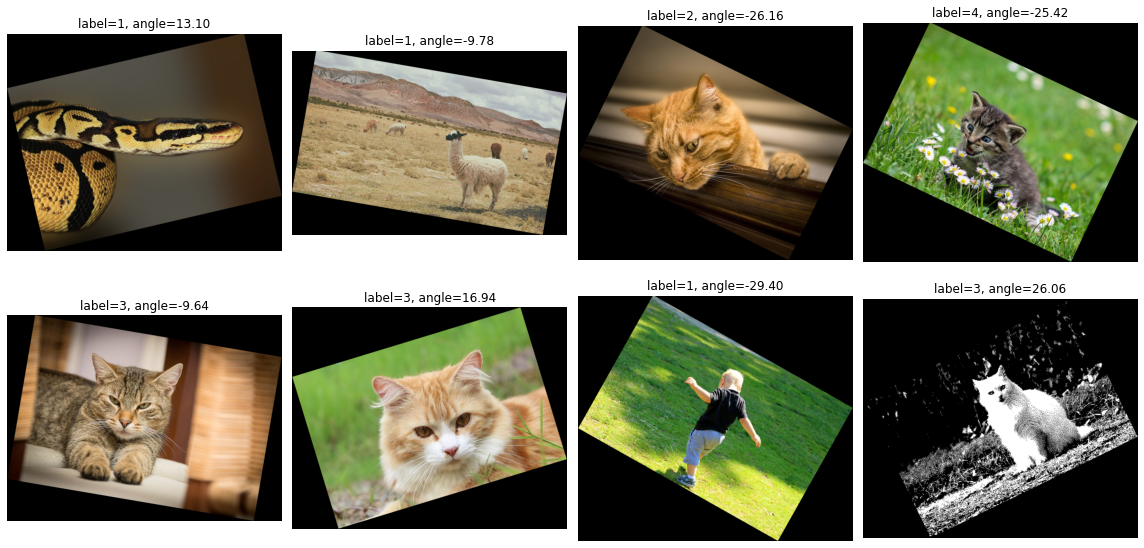

In [4]:
ref_jpegs, ref_labels = next(epoch)
ref_rotated, ref_labels, ref_angles = augment(ref_jpegs, ref_labels, rng)


def to_numpy_list(batch):
    return [np.array(sample) for sample in batch.cpu()]


ref_label_values = [int(t.flatten()[0]) for t in to_numpy_list(ref_labels)]
ref_angle_values = [float(t.flatten()[0]) for t in to_numpy_list(ref_angles)]

images_np = to_numpy_list(ref_rotated)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(images_np[i])
    ax.set_title(
        f"label={ref_label_values[i]}, angle={ref_angle_values[i]:.2f}"
    )
    ax.axis("off")
plt.tight_layout()
plt.show()

## Restoring from the checkpoint

On the restore side we build a fresh reader and a fresh RNG, load the saved checkpoint, and register both objects under the same names as before. `Checkpoint.register` applies the loaded state to each object as soon as it is added - the reader's state must be applied before its prefetch thread starts, so we do this *before* the first `next_epoch` call.

In [5]:
restored_reader = ndd.readers.File(
    file_root=IMAGE_DIR,
    random_shuffle=True,
    enable_checkpointing=True,
    name="image_reader",
)
restored_rng = ndd.random.RNG()

restored_ckpt = ndd.checkpoint.Checkpoint()
restored_ckpt.load("ndd_checkpoint_{seq:04d}.json")
restored_ckpt.register(restored_reader, "image_reader")
restored_ckpt.register(restored_rng, "rng")

restored_epoch = restored_reader.next_epoch(batch_size=BATCH_SIZE)
rest_jpegs, rest_labels = next(restored_epoch)
rest_rotated, rest_labels, rest_angles = augment(
    rest_jpegs, rest_labels, restored_rng
)

rest_label_values = [int(t.flatten()[0]) for t in to_numpy_list(rest_labels)]
rest_angle_values = [float(t.flatten()[0]) for t in to_numpy_list(rest_angles)]

## Verifying the resume

The labels track which files the reader picked, in order - matching labels mean the reader resumed at the right position and kept the same shuffle. Matching angles mean the RNG was restored to the same internal state.

In [6]:
print("labels (original): ", ref_label_values)
print("labels (restored): ", rest_label_values)
print("angles (original): ", [f"{a:.4f}" for a in ref_angle_values])
print("angles (restored): ", [f"{a:.4f}" for a in rest_angle_values])

assert ref_label_values == rest_label_values, "reader order diverged"
assert ref_angle_values == rest_angle_values, "RNG state diverged"
print("\nFile order and random angles match exactly.")

labels (original):  [1, 1, 2, 4, 3, 3, 1, 3]
labels (restored):  [1, 1, 2, 4, 3, 3, 1, 3]
angles (original):  ['13.1024', '-9.7800', '-26.1646', '-25.4199', '-9.6380', '16.9450', '-29.3992', '26.0642']
angles (restored):  ['13.1024', '-9.7800', '-26.1646', '-25.4199', '-9.6380', '16.9450', '-29.3992', '26.0642']

File order and random angles match exactly.


Finally, let's display the output.

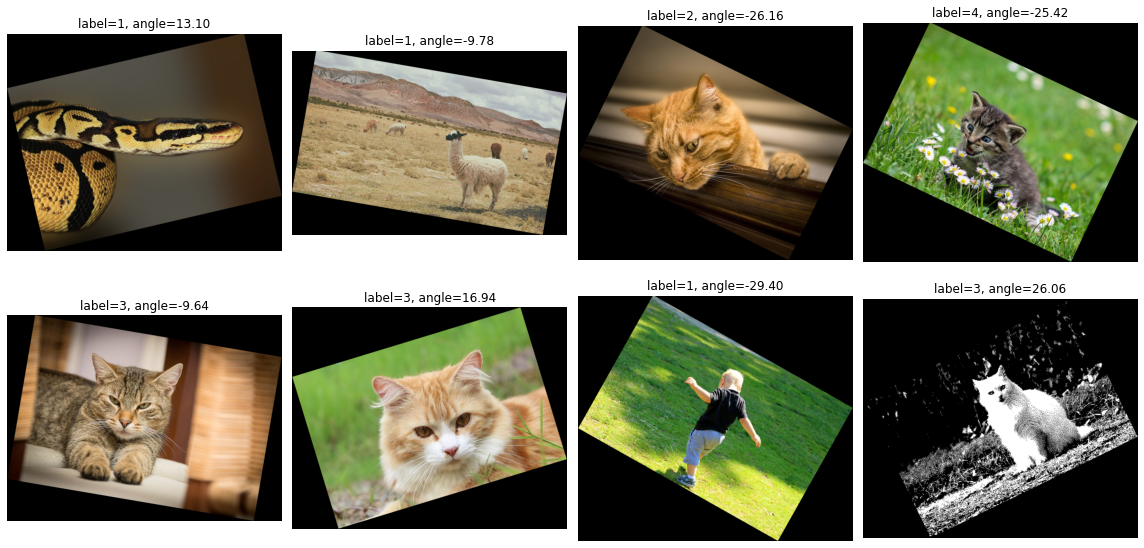

In [7]:
images_np = to_numpy_list(rest_rotated)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(images_np[i])
    ax.set_title(
        f"label={rest_label_values[i]}, angle={rest_angle_values[i]:.2f}"
    )
    ax.axis("off")
plt.tight_layout()
plt.show()